In [1]:
ROOT = "zigzag_results/mnist"

MODELS = {
    'vit_l_16': 'ViTl16',
    'vit_b_32': 'ViTb32',
    'resnet34': 'ResNet34'
}

N_COMPONENTS = [3, 4, 5]
PLOT_COMPONENT = 4

In [2]:
import os
import typing

def plan(model: str, n_components: int) -> typing.List[typing.Tuple[str, str, int]]:
    folder = f"{ROOT}/{model}"
    hs_folder = (
        f"{folder}/hidden_states"
        if os.path.exists(f"{folder}/hidden_states")
        else f"{folder}/features"
    )
    
    layers = os.listdir(hs_folder)
    if model == "vit_l_16" or model == "vit_b_32":
        layers = layers[1:]

    plan = []
    for hidden_state in layers:
        hs_no_ext = hidden_state[:hidden_state.index('.')]
        out_file = f"{folder}/spaces/{hs_no_ext}/{n_components}.txt"
        plan.append((f"{hs_folder}/{hs_no_ext}", out_file, n_components))
    return plan

In [3]:
import zigzag.space

params = []
for model in MODELS.keys():
    for n_components in N_COMPONENTS:
        params.extend(plan(model, n_components))
zigzag.space.process_bulk(params, n_jobs=4)
None

 93%|█████████▎| 148/159 [2:16:16<06:55, 37.74s/it]   d:\Programs\Programming\Python\lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(
100%|██████████| 159/159 [2:28:47<00:00, 56.15s/it]


In [4]:
import pandas

report = []
for model, title in MODELS.items():
    for n_components in N_COMPONENTS:
        item = zigzag.space.make_report(plan(model, n_components))
        report.append({'model': title, 'n_components': n_components, **item})

report = pandas.DataFrame(report)
report.to_csv(f"{ROOT}/spaces_report.csv")
report

100%|██████████| 17/17 [00:00<?, ?it/s]


,model,n_components,layer_1,layer_2,layer_3,layer_4,layer_5,layer_6,layer_7,layer_8,...,layer_15,layer_16,layer_17,layer_18,layer_19,layer_20,layer_21,layer_22,layer_23,layer_24
0,ViTl16,3,"75.6%\n(1, 0, 0)\n(1, 0, 0)","45.7%\n(2, 2, 1)\n(2, 2, 1)","44.7%\n(2, 1, 1)\n(2, 1, 1)","43.2%\n(2, 1, 1)\n(2, 1, 1)","40.4%\n(2, 12, 15)\n(2, 12, 15)","39.5%\n(2, 1, 1)\n(2, 1, 1)","39.8%\n(3, 2, 6)\n(3, 2, 6)","39.9%\n(3, 5, 1)\n(3, 5, 1)",...,"39.0%\n(3, 4, 1)\n(3, 4, 1)","39.3%\n(3, 1, 3)\n(3, 1, 3)","39.3%\n(3, 1, 3)\n(3, 1, 3)","75.6%\n(1, 0, 0)\n(1, 0, 0)","67.4%\n(1, 0, 0)\n(1, 0, 0)","60.5%\n(2, 1, 0)\n(2, 1, 0)","51.3%\n(2, 1, 1)\n(2, 1, 1)","47.7%\n(3, 3, 1)\n(3, 3, 1)","48.0%\n(2, 1, 2)\n(2, 1, 2)","47.3%\n(2, 1, 1)\n(2, 1, 1)"
1,ViTl16,4,"82.1%\n(1, 0, 0, 0)\n(1, 0, 0, 0)","52.2%\n(3, 2, 1, 1)\n(3, 2, 1, 1)","50.9%\n(3, 2, 3, 1)\n(3, 2, 3, 1)","49.5%\n(3, 2, 6, 3)\n(3, 2, 6, 3)","46.1%\n(3, 2, 1, 2)\n(3, 2, 1, 2)","45.4%\n(3, 1, 1, 1)\n(3, 1, 1, 1)","45.6%\n(3, 1, 2, 1)\n(3, 1, 2, 1)","45.6%\n(3, 1, 1, 1)\n(3, 1, 1, 1)",...,"44.5%\n(3, 2, 2, 1)\n(3, 2, 2, 1)","44.7%\n(3, 2, 2, 1)\n(3, 2, 2, 1)","44.7%\n(3, 2, 2, 1)\n(3, 2, 2, 1)","78.4%\n(1, 0, 0, 0)\n(1, 0, 0, 0)","71.7%\n(1, 0, 0, 0)\n(1, 0, 0, 0)","66.1%\n(2, 1, 0, 0)\n(2, 1, 0, 0)","56.8%\n(2, 1, 1, 0)\n(2, 1, 1, 0)","53.7%\n(3, 1, 1, 0)\n(3, 1, 1, 0)","54.2%\n(6, 1, 1, 0)\n(6, 1, 1, 0)","53.6%\n(2, 1, 1, 1)\n(2, 1, 1, 1)"
2,ViTl16,5,"85.6%\n(1, 1, 0, 0, 0)\n(1, 1, 0, 0, 0)","56.9%\n(4, 1, 1, 2, 1)\n(4, 1, 1, 2, 1)","55.6%\n(7, 1, 15, 8, 0)\n(7, 1, 15, 8, 0)","54.2%\n(3, 5, 2, 1, 0)\n(3, 5, 2, 1, 0)","51.6%\n(3, 10, 8, 1, 0)\n(3, 10, 8, 1, 0)","50.6%\n(3, 2, 3, 3, 0)\n(3, 2, 3, 3, 0)","50.6%\n(3, 2, 1, 8, 0)\n(3, 2, 1, 8, 0)","50.4%\n(3, 1, 1, 2, 0)\n(3, 1, 1, 2, 0)",...,"49.2%\n(3, 1, 1, 1, 0)\n(3, 1, 1, 1, 0)","49.4%\n(3, 2, 2, 5, 0)\n(3, 2, 2, 5, 0)","49.4%\n(3, 2, 2, 5, 0)\n(3, 2, 2, 5, 0)","81.1%\n(1, 0, 0, 0, 0)\n(1, 0, 0, 0, 0)","75.6%\n(1, 0, 0, 0, 0)\n(1, 0, 0, 0, 0)","70.4%\n(3, 1, 0, 0, 0)\n(3, 1, 0, 0, 0)","61.2%\n(2, 2, 1, 0, 0)\n(2, 2, 1, 0, 0)","58.7%\n(2, 1, 1, 1, 0)\n(2, 1, 1, 1, 0)","59.3%\n(2, 1, 1, 1, 0)\n(2, 1, 1, 1, 0)","58.1%\n(2, 4, 10, 4, 0)\n(2, 4, 10, 4, 0)"
3,ViTb32,3,"63.2%\n(1, 0, 0)\n(1, 0, 0)","43.1%\n(1, 0, 0)\n(1, 0, 0)","44.5%\n(1, 0, 0)\n(1, 0, 0)","63.2%\n(1, 2, 0)\n(1, 2, 0)","67.7%\n(1, 0, 0)\n(1, 0, 0)","62.8%\n(1, 0, 0)\n(1, 0, 0)","61.8%\n(1, 0, 0)\n(1, 0, 0)","60.3%\n(1, 0, 0)\n(1, 0, 0)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,ViTb32,4,"71.2%\n(1, 0, 0, 0)\n(1, 0, 0, 0)","49.7%\n(1, 1, 0, 0)\n(1, 1, 0, 0)","51.3%\n(1, 2, 0, 0)\n(1, 2, 0, 0)","67.6%\n(2, 3, 1, 0)\n(2, 3, 1, 0)","73.4%\n(1, 0, 0, 0)\n(1, 0, 0, 0)","68.4%\n(1, 0, 0, 0)\n(1, 0, 0, 0)","66.1%\n(1, 0, 0, 0)\n(1, 0, 0, 0)","65.1%\n(1, 0, 0, 0)\n(1, 0, 0, 0)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,ViTb32,5,"77.4%\n(1, 0, 0, 0, 0)\n(1, 0, 0, 0, 0)","53.8%\n(7, 5, 0, 0, 0)\n(7, 5, 0, 0, 0)","55.5%\n(3, 1, 0, 0, 0)\n(3, 1, 0, 0, 0)","70.4%\n(2, 3, 2, 0, 0)\n(2, 3, 2, 0, 0)","77.0%\n(1, 0, 0, 0, 0)\n(1, 0, 0, 0, 0)","70.9%\n(1, 0, 0, 0, 0)\n(1, 0, 0, 0, 0)","69.9%\n(1, 0, 0, 0, 0)\n(1, 0, 0, 0, 0)","68.0%\n(1, 0, 0, 0, 0)\n(1, 0, 0, 0, 0)",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,ResNet34,3,"33.9%\n(8, 3, 2)\n(8, 3, 2)","34.8%\n(2, 4, 1)\n(2, 4, 1)","16.6%\n(3, 3, 4)\n(3, 3, 4)","16.5%\n(2, 1, 3)\n(2, 1, 3)","15.9%\n(3, 1, 2)\n(3, 1, 2)","15.8%\n(2, 1, 1)\n(2, 1, 1)","20.5%\n(2, 3, 1)\n(2, 3, 1)","21.4%\n(3, 3, 1)\n(3, 3, 1)",...,"26.4%\n(2, 2, 13)\n(2, 2, 13)","15.5%\n(4, 5, 1)\n(4, 5, 1)","16.5%\n(4, 1, 5)\n(4, 1, 5)",NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,ResNet34,4,"39.0%\n(6, 1, 1, 1)\n(6, 1, 1, 1)","39.8%\n(2, 2, 1, 2)\n(2, 2, 1, 2)","20.4%\n(4, 1, 1, 1)\n(4, 1, 1, 1)","20.4%\n(4, 1, 16, 5)\n(4, 1, 16, 5)","20.0%\n(2, 4, 4, 1)\n(2, 4, 4, 1)","20.0%\n(2, 3, 1, 1)\n(2, 3, 1, 1)","25.1%\n(3, 1, 3, 2)\n(3, 1, 3, 2)","26.4%\n(2, 9, 6, 3)\n(2, 9, 6, 3)",...,"29.5%\n(6, 2, 4, 3)\n(6, 2, 4, 3)","19.0%\n(2, 1, 3, 1)\n(2, 1, 3, 1)","20.2%\n(2, 2, 2, 8)\n(2, 2, 2, 8)",Na

100%|██████████| 17/17 [00:00<?, ?it/s]


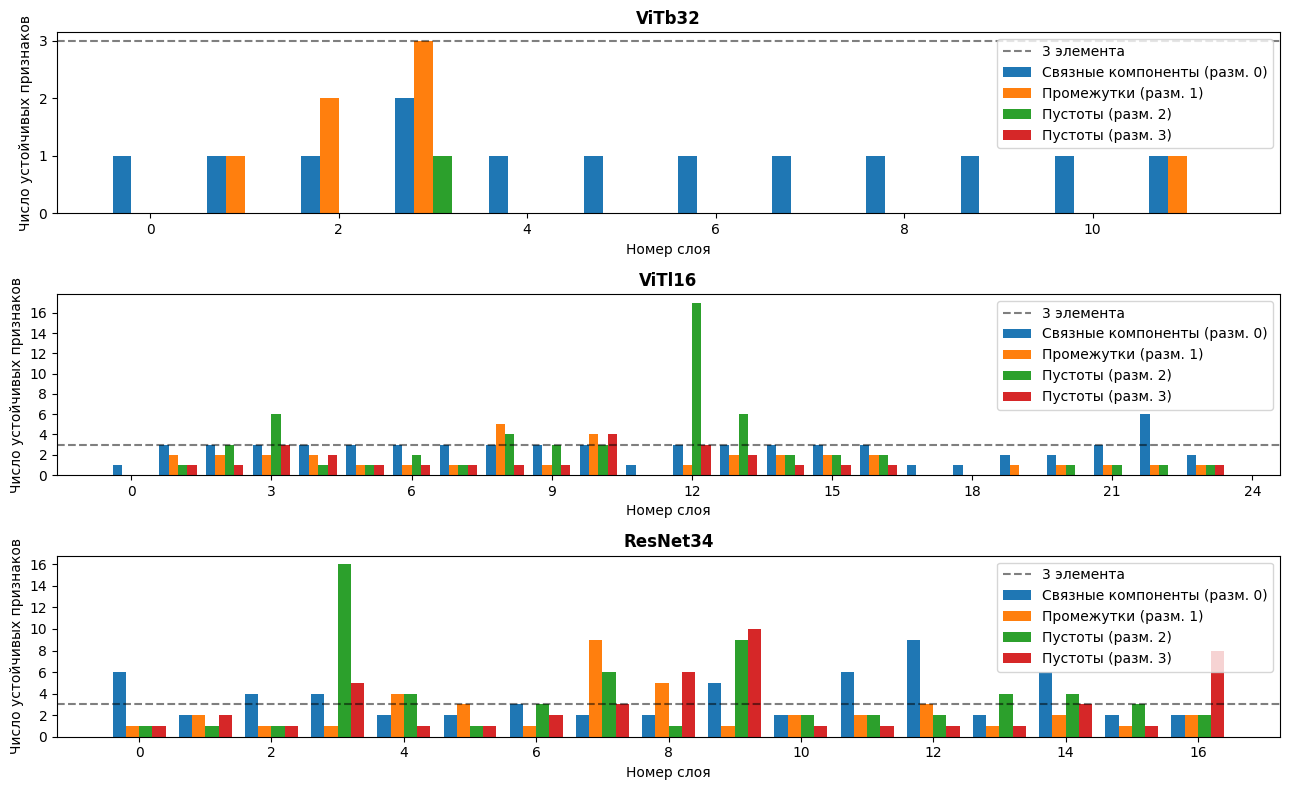

In [5]:
import matplotlib.pyplot as plt

AX_IDX = { 'vit_l_16': 1, 'vit_b_32': 0, 'resnet34': 2 }
fig, axes = plt.subplots(3, 1, figsize = (13, 8))
for model, title in MODELS.items():
    ax = axes.flat[AX_IDX[model]]
    ax.set_title(title, fontweight='bold')
    zigzag.space.plot(plan(model, PLOT_COMPONENT), ax)
    ax.axhline(
        y=3, color='black', linestyle='dashed', alpha=0.5, label='3 элемента'
    )
    ax.legend(loc='best')

fig.tight_layout()
fig.savefig(f"{ROOT}/spaces_plots.png")
fig.savefig(f"{ROOT}/spaces_plots.svg")